In [ ]:
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Ejecución en local")

# TENER EN CUENTA DESDE DÓNDE ESTAMOS EJECUTANDO PARA ENCONTRAR EL REQUIREMENTS
BASE_PATH = Path("/content/drive/MyDrive/TFMCode") if IN_COLAB else Path("..").resolve()

if IN_COLAB:
    drive.mount('/content/drive')
    print("Ejecución en colab")

    %pip install -r "{BASE_PATH}/requirements.txt"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ejecución en colab


In [24]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel
from sklearn.neighbors import KNeighborsRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning
# silenciamos los warnings de convergencia porque hemos visto que el modelo ya ha alcanzado su límite de rendimiento y no mejora aunque cambiemos los parámetros
warnings.filterwarnings('ignore', category=ConvergenceWarning)
import sys
from pathlib import Path
# útiles
UTILS_PATH = BASE_PATH / "utils"
sys.path.append(str(UTILS_PATH))
# data
DATA_PATH = BASE_PATH / "data"
sys.path.append(str(DATA_PATH))
# clase y función del archivo py de la carpeta utils
from protocolo_evaluacion import (PerformanceEvaluator, run_benchmarked_inference)

# MAN1: escenario de alta densidad local

A la hora de implementar las técnicas de alivio a aplicar en el dataset MAN1, vamos a crear un pipeline de dos fases principales: suavizado y regresión por procesos gaussianos.

## Función de suavizado

En primer lugar, vamos a aplicar la función de suavizado, que agrupará las 14300 huellas por coordenadas únicas calculando la media.

In [ ]:
def apply_spatial_smoothing(train_rss, train_crd):
    """
    Agrupa las huellas por coordenadas únicas, calcula la media para obtener puntos limpios
    """
    # creamos copias locales para proteger los df originales
    rss_df = train_rss.copy()
    crd_df = train_crd.copy()

    #renombramos las coordenadas a strings únicos
    crd_df.columns = [f'COORD_{i}' for i in range(crd_df.shape[1])]
    coord_cols = list(crd_df.columns)

    # combinamos temporalmente para agrupar de forma unificada
    full_train = pd.concat([crd_df, rss_df], axis=1)

    # agrupamos por coordenada y sacamos la media
    smoothed_df = full_train.groupby(coord_cols).mean().reset_index()

    x_smoothed = smoothed_df[coord_cols].values
    y_smoothed = smoothed_df.drop(columns=coord_cols).values

    print(f"Suavizado hecho. Longitud inicial {len(train_rss)}, longitud final {len(x_smoothed)}")
    return x_smoothed, y_smoothed

Una vez que tenemos la función de suavizado podemos realizar el pipeline de optimización y conectarlo con la evaluación del GPR

In [ ]:
def tune_gpr_pipeline(x_train_raw, y_train_raw, x_test, y_test, best_knn_k, best_knn_metric, iterations):
    """
    Realiza búsqueda de rejilla sobre los hiperparámetros del GPR, genera el mapa sintético, evalúa el rendimiento final
    """
    # llamamos a la función de suavizado pasándole RSS y coordenadas cruzas y retornando los df suavizados
    x_train_space, y_train_space = apply_spatial_smoothing(y_train_raw, x_train_raw)

    # definimos de la rejilla de parámetros
    candidate_kernels = {
        # con length_scale y length_scale_bounds indicamos el radio de influencia de la medición. Indicamos el rango 1e-1 a 1e5 para abarcar de pocos centrímetros a muchos metros
        # el noise_level de 0,1 absorbe de forma estadística el ruido y las fluctuaciones de las 110 capturas, actúa como colchón para que el GPR no sobreajuste
        'RBF': RBF(length_scale=10.0, length_scale_bounds=(1e-1, 1e5)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-7, 1e2)),
        # para la definción del kernel Matérn indicamos el valor de nu 0,5 (1/2), 1,5 (3/2) y 2,5 (5/2), que son los valores más habituales
        'Matern_0.5': Matern(length_scale=10.0, nu=0.5, length_scale_bounds=(1e-1, 1e5)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-7, 1e2)),
        'Matern_1.5': Matern(length_scale=10.0, nu=1.5, length_scale_bounds=(1e-1, 1e5)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-7, 1e2)),
        'Matern_2.5': Matern(length_scale=10.0, nu=2.5, length_scale_bounds=(1e-1, 1e5)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-7, 1e2))
    }
    # con normalize true indicamos media 0 y con false indicamos media constante, donde el optimizador encuentra el valor base más adecuado para el mapa
    normalize_options = [True, False]

    # inicializamos variables para empezar las iteraciones
    best_mae = float('inf')
    best_gpr_results = None
    best_evaluator = None
    gpr_logs = []

    # con shape[1] sobre y_train_space accedemos al valor de APs, es decir, 28 para MAN1
    num_aps = y_train_space.shape[1]

    # iteramos sobre los kernels y sobre las opcines de normalización
    for kernel_name, base_kernel in candidate_kernels.items():
        for norm_y in normalize_options:
            print(f"\nEvaluando Configuración GPR con kernel {kernel_name} y normalización {norm_y}")

            # lista para almacenar los 28 modelos GPR de esta iteración
            trained_gps = []

            # entrenamos un GPR independiente por cada AP utilizando los 130 puntos suavizados
            # instanciamos un objeto regresor de la clase GaussianProcessRegressor con los parámetros de la iteración en curso y añadimos el modelo entrenado a la lista
            for ap_idx in range(num_aps):
                gp = GaussianProcessRegressor(kernel=base_kernel, normalize_y=norm_y, random_state=1)
                gp.fit(x_train_space, y_train_space[:, ap_idx])
                trained_gps.append(gp)

            # creamos el mapa de radio sintético
            # reconstruimos la matriz de señales estimadas sobre las 130 posiciones reales
            synthetic_rss_train = np.zeros_like(y_train_space)
            for ap_idx in range(num_aps):
                synthetic_rss_train[:, ap_idx] = trained_gps[ap_idx].predict(x_train_space)


            # configuramos el asignador k-NN fijando los mejores parámetros del baseline anterior
            knn_matcher = KNeighborsRegressor(n_neighbors=best_knn_k, metric=best_knn_metric, weights='uniform')
            # entrenamos el asignador usando el mapa sintético reducido de 130 muestras
            knn_matcher.fit(synthetic_rss_train, x_train_space)

            # perparamos los arrays para test
            # señales RSS con los 28 APs
            test_rss_input = y_test.values if hasattr(y_test, 'values') else y_test
            # coordenadas reales
            test_crd_true = x_test.values if hasattr(x_test, 'values') else x_test

            # medimos el tiempo de inferencia con el benchmark llamando a la función de los utils
            y_pred_crd, avg_time, _ = run_benchmarked_inference(
                model=knn_matcher,
                test_data=test_rss_input,
                iterations=iterations
            )

            # instanciamos un objeto evaluador de la clase PerformanceEvaluator para evaluar la precisión espacial
            evaluator = PerformanceEvaluator("MAN1")
            res = evaluator.calculate_precision(
                y_true=test_crd_true,
                y_pred=y_pred_crd
            )

            # añadimos las métricas
            res['kernel'] = kernel_name
            res['normalize_y'] = norm_y
            res['MTQ_ms'] = (avg_time / len(x_test)) * 1000
            res['Reduction_Factor'] = (1 - (len(x_train_space) / len(x_train_raw))) * 100

            gpr_logs.append(res)
            print(f"Resultado: MAE = {res['MAE_2D']:.2f}m, reducción mapa = {res['Reduction_Factor']:.2f}%")

            if res['MAE_2D'] < best_mae:
                best_mae = res['MAE_2D']
                best_gpr_results = res
                best_evaluator = evaluator

    return pd.DataFrame(gpr_logs), best_gpr_results, best_evaluator

Para poner en marcha el pipeline debemos llamar a la función que acabamos de crear con las variables de los conjuntos de datos limpios de MAN1 y los parámetros ganadores que descubrimos en el apartado de la obtención del sistema de referencia.

In [ ]:
# importamos los archivos de train y test de RSS y de coordenadas
man1_train_rss = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_trnrss_clean.csv", header=None)
man1_test_rss = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_tstrss_clean.csv", header=None)
man1_train_crd = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_trncrd_clean.csv", header=None)
man1_test_crd = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_tstcrd_clean.csv", header=None)

In [25]:
# fijamos los hiperparámetros ganadores del baseline kNN para MAN1
best_k_man1 = 15
best_metric_man1 = 'manhattan'

# llamamos a la función para poner en marcha el pipeline y afinar el GPR
gpr_logs_df, best_gpr_results, gpr_evaluator = tune_gpr_pipeline(
    x_train_raw = man1_train_crd,
    y_train_raw = man1_train_rss,
    x_test = man1_test_crd,
    y_test = man1_test_rss,
    best_knn_k = best_k_man1,
    best_knn_metric = best_metric_man1,
    iterations = 5
)

Suavizado hecho. Longitud inicial 14300, longitud final 130

Evaluando Configuración GPR con kernel RBF y normalización True
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 4.86 ms, desviación: 0.14 ms
Resultado: MAE = 2.92m, reducción mapa = 99.09%

Evaluando Configuración GPR con kernel RBF y normalización False
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 4.83 ms, desviación: 0.25 ms
Resultado: MAE = 2.95m, reducción mapa = 99.09%

Evaluando Configuración GPR con kernel Matern_0.5 y normalización True
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 5.14 ms, desviación: 0.41 ms
Resultado: MAE = 2.95m, reducción mapa = 99.09%

Evaluando Configuración GPR con kernel Matern_0.5 y normalización False
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 4.81 ms, desviación: 0.18 ms
Resultado: MAE = 2.95m, reducción mapa = 99.09%

Evaluando Configuración GPR con kernel Matern_1.5 y normalización True
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 5.06 ms, desviación: 0.4

Ahora que tenemos la información sobre los resultados del mejor GPR podemos examinar el veredicto del optimizador

Mejor configuración GPR
MAE_2D: 2.9173
P75: 3.9872
P95: 6.0028
kernel: RBF
normalize_y: True
MTQ_ms: 0.0106
Reduction_Factor: 99.0909
     MAE_2D       P75       P95      kernel  normalize_y    MTQ_ms  \
0  2.917280  3.987233  6.002831         RBF         True  0.010563   
4  2.926112  4.006630  5.825479  Matern_1.5         True  0.010999   
7  2.929658  3.990909  6.022289  Matern_2.5        False  0.010735   
6  2.931150  3.993663  5.902927  Matern_2.5         True  0.011928   
5  2.933192  4.006630  5.965236  Matern_1.5        False  0.010346   
1  2.945535  4.118859  5.930726         RBF        False  0.010499   
3  2.947366  4.037635  6.221592  Matern_0.5        False  0.010452   
2  2.952022  4.037635  6.221592  Matern_0.5         True  0.011168   

   Reduction_Factor  
0         99.090909  
4         99.090909  
7         99.090909  
6         99.090909  
5         99.090909  
1         99.090909  
3         99.090909  
2         99.090909  


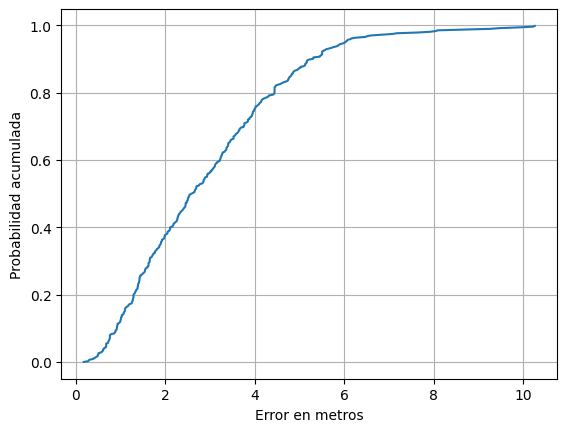

In [26]:
# vemos la configuración óptima de media y kernel encontrada
print("Mejor configuración GPR")
for metrica, valor in best_gpr_results.items():
    if isinstance(valor, float):
        print(f"{metrica}: {valor:.4f}")
    else:
        print(f"{metrica}: {valor}")

# mostramos la tabla comparativa ordenando por MAE
print(gpr_logs_df.sort_values(by='MAE_2D', ascending=True))
# imprimimos la curva de CDF
gpr_evaluator.plot_cdf()